<div style="background:#1F3864;padding:22px 28px;border-radius:10px;margin-bottom:14px">
<h2 style="color:#A8C8E8;margin:0 0 6px">Digitalization, AI &amp; XAI in Healthcare</h2>
<h1 style="color:#FFFFFF;margin:0 0 10px;font-size:1.45em">NB18_BONUS-1/2 — Adversarial Attacks on Medical CNN: Seven Methods on PneumoniaMNIST</h1>
<p style="color:#BDD7EE;margin:0;font-size:.95em"><strong>Module 6: Application Workshop: Design of an Explainable AI Solution</strong></p>
<p style="color:#9DC3E6;margin:4px 0 0;font-size:.88em">Sections: S1: PneumoniaMNIST CNN · S2: Seven Attacks (FGSM · PGD · C&amp;W · DeepFool · One-Pixel · Boundary · Surrogate) · S3: Grad-CAM XAI Under Attack</p>
</div>

## Learning Objectives

1. **Build** a medical CNN fine-tuned on PneumoniaMNIST chest X-rays as a clinically realistic attack surface
2. **Apply** all seven adversarial attack families — FGSM, PGD, Carlini-Wagner, DeepFool, One-Pixel, Boundary, and Surrogate-Transfer — to the medical CNN
3. **Compare** attacks across three dimensions: attack success rate (ASR), L2 distortion, and L∞ distortion
4. **Inspect** each attack through **Grad-CAM** — observe how the CNN’s attention region shifts or collapses under perturbation
5. **Understand** the clinical stakes: a successful attack can suppress a pneumonia alert for a child

> **Dataset:** PneumoniaMNIST (Kermany et al. 2018, Yang et al. 2023) — 624 real paediatric chest X-rays.
> **NB19** continues with GEMEX geodesic detection and four defence methods.

**References:** Goodfellow et al. (2015). | Madry et al. (2018). | Carlini & Wagner (2017).
Moosavi-Dezfooli et al. (2016). | Su et al. (2019). | Brendel et al. (2018). | Papernot et al. (2016).

---

## Setup

```bash
pip install medmnist tensorflow adversarial-robustness-toolbox
pip install opencv-python-headless scikit-image scikit-learn matplotlib scipy
# GPU strongly recommended for C&W and Boundary attacks
```

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, io, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, optimizers
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.ndimage import gaussian_filter
from scipy.optimize import differential_evolution

NAVY='#1F3864'; BLUE='#2E75B6'; GREEN='#1F7A5C'
RED='#C0392B'; ORANGE='#D4860B'; PURPLE='#7B3F9E'; GREY='#6C757D'; TEAL='#117A8B'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus: tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU: {len(gpus)} device(s) ready')
else:
    print('CPU mode (GPU recommended for C&W and Boundary attacks)')

IMG_SIZE=224; N_CLASSES=2; CLASS_NAMES=['Normal','Pneumonia']
print(f'TF {tf.__version__} | NB18_BONUS-1/2 — Adversarial Attacks on Medical CNN: Seven Methods on PneumoniaMNIST')

CPU mode (GPU recommended for C&W and Boundary attacks)
TF 2.21.0 | NB18_BONUS-1/2 — Adversarial Attacks on Medical CNN: Seven Methods on PneumoniaMNIST


---
## Section 1 — PneumoniaMNIST CNN: Real Medical Image Classifier

> We use the **PneumoniaMNIST test split** (624 real chest X-rays) as our attack surface.
> CNN is fine-tuned on the training split — the same architecture and dataset as NB19.
> This gives us a clinically realistic target: a production-grade medical CNN.

**Why this matters clinically:** A successful adversarial attack on this model could cause a
pneumonia case to be classified as normal, delaying treatment for a child.

**Reference:** Kermany, D. S. et al. (2018). *Cell, 172*(5), 1122–1131.

In [2]:
# ── Load PneumoniaMNIST at 64×64 — robust to medmnist version differences ────
LOAD_SIZE = 64       # safe on CPU-only servers (~195 MB for full train split)
IMG_SIZE  = 64       # model trains at 64×64 — fast on CPU, no resize needed
MAX_TRAIN = 800      # cap training samples for speed

def safe_label(label):
    '''Convert any medmnist label format to a plain Python int.
    Handles: scalar int, np.int64, np.array shape (), np.array shape (1,),
             np.array shape (1,1) — all medmnist versions seen in the wild.
    '''
    return int(np.asarray(label).ravel()[0])

def to_numpy(ds):
    '''Convert a medmnist Dataset to (X, y) numpy arrays.
    Images: float32 in [0,1], shape (N, H, W, 3).
    Labels: int32 1-D array.
    '''
    imgs, labels = [], []
    for img, label in ds:
        arr = np.array(img)
        if arr.ndim == 2:          arr = np.stack([arr]*3, axis=-1)
        elif arr.shape[-1] == 1:   arr = np.concatenate([arr]*3, axis=-1)
        imgs.append(arr.astype(np.float32) / 255.0)
        labels.append(safe_label(label))
    return np.array(imgs), np.array(labels, dtype=np.int32)

try:
    import medmnist
    from medmnist import PneumoniaMNIST
    print(f'medmnist {medmnist.__version__} found.')

    # Quick label-format probe before loading the full dataset
    _probe = PneumoniaMNIST(split='test', download=True, size=LOAD_SIZE)
    _, _lbl = _probe[0]
    print(f'Label probe: type={type(_lbl)}, '
          f'shape={getattr(np.asarray(_lbl),"shape","N/A")}, '
          f'safe_label={safe_label(_lbl)}')

    print(f'Loading PneumoniaMNIST at {LOAD_SIZE}×{LOAD_SIZE}...')
    X_tr_small, y_tr = to_numpy(
        PneumoniaMNIST(split='train', download=True, size=LOAD_SIZE))
    X_te_small, y_te = to_numpy(
        PneumoniaMNIST(split='test',  download=True, size=LOAD_SIZE))

    # Cap training set
    rng_cap = np.random.default_rng(42)
    cap_idx = rng_cap.choice(len(X_tr_small),
                              min(MAX_TRAIN, len(X_tr_small)), replace=False)
    X_tr_small = X_tr_small[cap_idx]
    y_tr       = y_tr[cap_idx]
    USE_REAL   = True
    print(f'Train (capped): {X_tr_small.shape}  Test: {X_te_small.shape}')
    print(f'Test  — Normal: {(y_te==0).sum()}, Pneumonia: {(y_te==1).sum()}')

except Exception as e:
    print(f'medmnist load failed ({type(e).__name__}: {e})')
    print('Falling back to synthetic placeholder — results will be illustrative only.')
    rng = np.random.default_rng(42)
    # Structured synthetic: class-conditional blobs to give the model real signal
    def _make_image(label, rng):
        '''Generate one synthetic chest X-ray image.
        Normal    (0): dark uniform background, no blob
        Pneumonia (1): dark background + bright consolidation blob
                       Blob position/size randomised so model must learn
                       the blob feature, not a fixed location.
        '''
        img = rng.uniform(0.1, 0.3,
                           (LOAD_SIZE, LOAD_SIZE, 3)).astype(np.float32)
        if label == 1:
            # Randomise blob position and radius
            cx  = rng.integers(LOAD_SIZE//4, 3*LOAD_SIZE//4)
            cy  = rng.integers(LOAD_SIZE//4, 3*LOAD_SIZE//4)
            r   = rng.integers(LOAD_SIZE//8, LOAD_SIZE//4)
            yy, xx = np.ogrid[:LOAD_SIZE, :LOAD_SIZE]
            blob = ((xx-cx)**2 + (yy-cy)**2) < r**2
            img[blob] = rng.uniform(0.7, 0.95, (blob.sum(), 3)).astype(np.float32)
        return img

    def _synthetic_split(n):
        # Strictly balanced 50/50
        n_each = n // 2
        imgs, labs = [], []
        for lbl in [0, 1]:
            for i in range(n_each):
                imgs.append(_make_image(lbl, rng))
                labs.append(lbl)
        idx = rng.permutation(len(imgs))
        return (np.array(imgs, dtype=np.float32)[idx],
                np.array(labs,  dtype=np.int32)[idx])

    X_tr_small, y_tr   = _synthetic_split(MAX_TRAIN)
    X_te_small, y_te   = _synthetic_split(120)
    USE_REAL = False
    print(f'Synthetic train: {X_tr_small.shape}  test: {X_te_small.shape}')

import tensorflow as tf

# No resize needed — model runs at LOAD_SIZE=64
X_te = X_te_small.copy()
print(f'Test set: {X_te.shape}  ({X_te.nbytes/1e6:.0f} MB)')

# Attack targets: 15 Normal + 15 Pneumonia — balanced so ASR is meaningful
# Using only one class means ASR=0 if model is biased toward that class.
norm_idx  = np.where(y_te == 0)[0][:15]
pneu_idx  = np.where(y_te == 1)[0][:15]
mix_idx   = np.concatenate([norm_idx, pneu_idx])
X_attack  = X_te[mix_idx]
y_attack  = y_te[mix_idx]
print(f'Attack targets: {len(X_attack)} images  '
      f'Normal={sum(y_attack==0)}  Pneumonia={sum(y_attack==1)}')
print(f'USE_REAL={USE_REAL}')

medmnist 3.0.2 found.
Label probe: type=<class 'numpy.ndarray'>, shape=(1,), safe_label=1
Loading PneumoniaMNIST at 64×64...
Train (capped): (800, 64, 64, 3)  Test: (624, 64, 64, 3)
Test  — Normal: 234, Pneumonia: 390
Test set: (624, 64, 64, 3)  (31 MB)
Attack targets: 30 images  Normal=15  Pneumonia=15
USE_REAL=True


In [3]:
# ── Lightweight CNN — deliberately calibrated for adversarial teachability ────
# Architecture note: we intentionally use a SHALLOWER model with NO BatchNorm
# and higher Dropout. This gives ~75-85% clean accuracy with a soft decision
# boundary — realistic for a model in early deployment and easy to attack,
# which is exactly the adversarial vulnerability we want to demonstrate.
# A 3-layer BN model reaches 99%+ accuracy on this synthetic data, making
# all gradient-based attacks fail (wide margin = large perturbation needed).

def build_model():
    reg = tf.keras.regularizers.l2(1e-4)
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(16, 3, padding='same', activation='relu',
                       kernel_regularizer=reg)(inp)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                       kernel_regularizer=reg)(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(32, activation='relu',
                      kernel_regularizer=reg, name='embedding')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(N_CLASSES, activation='softmax', dtype='float32')(x)
    return tf.keras.Model(inp, out, name='PneumoniaCNN')

model = build_model()
model.compile(
    optimizer=optimizers.Adam(3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
cb = [tf.keras.callbacks.EarlyStopping(
        patience=8, restore_best_weights=True, monitor='val_loss')]
X_tr = X_tr_small.copy()
print('Training CNN (shallow, no BN, high dropout — ~75-85% target acc)...')
model.fit(X_tr, y_tr,
           validation_split=0.15, epochs=40,
           batch_size=32, callbacks=cb, verbose=1)

clean_preds = np.argmax(model.predict(X_te, verbose=0), axis=1)
clean_acc   = accuracy_score(y_te, clean_preds)
print(f'\nClean test accuracy: {clean_acc:.3f}')
unique_preds = np.unique(clean_preds)
if len(unique_preds) == 1:
    print('WARNING: model still predicts one class — increase epochs manually.')
else:
    print(f'Normal={sum(clean_preds==0)}  Pneumonia={sum(clean_preds==1)}')

# Print softmax confidence to verify soft boundary
probs = model.predict(X_te[:10], verbose=0)
print(f'Mean max-confidence on test set: {probs.max(axis=1).mean():.3f}')
print('(Values 0.6-0.85 indicate soft boundary — good for attacks)')
print('(Values >0.95 indicate hard boundary — attacks will fail)')

# ART wrapper
try:
    from art.estimators.classification import TensorFlowV2Classifier
    loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    art_clf = TensorFlowV2Classifier(
        model=model, nb_classes=N_CLASSES,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        loss_object=loss_obj, clip_values=(0., 1.))
    ART_OK = True
    print('ART classifier wrapper ready.')
except ImportError:
    ART_OK = False
    print('ART not installed — using custom attack implementations.')

Training CNN (shallow, no BN, high dropout — ~75-85% target acc)...
Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7000 - loss: 0.6364 - val_accuracy: 0.7000 - val_loss: 0.6220
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7544 - loss: 0.5706 - val_accuracy: 0.7000 - val_loss: 0.6209
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7544 - loss: 0.5781 - val_accuracy: 0.7000 - val_loss: 0.6189
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7544 - loss: 0.5782 - val_accuracy: 0.7000 - val_loss: 0.6178
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7544 - loss: 0.5777 - val_accuracy: 0.7000 - val_loss: 0.6169
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7544 - loss: 0.5753 - val_accuracy: 0.7000 - val_loss: 0.6186
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7544 - loss: 0.5710 - val_accuracy: 0.7000 - val_loss: 0.6138
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24

---
## Section 2 — Attack Zoo: All Seven Methods on PneumoniaMNIST

Seven attack families adapted to the medical CNN:

| # | Attack | Type | Access | Key idea |
|---|--------|------|--------|----------|
| 1 | **FGSM** | Evasion | White-box | Single gradient step (Goodfellow 2015) |
| 2 | **PGD** | Evasion | White-box | Iterated FGSM with projection (Madry 2018) |
| 3 | **Carlini-Wagner L2** | Evasion | White-box | Optimisation with confidence term (C&W 2017) |
| 4 | **DeepFool** | Evasion | White-box | Minimal perturbation to nearest boundary (Moosavi-Dezfooli 2016) |
| 5 | **One-Pixel** | Evasion | Black-box | Differential evolution, modifies 1 pixel (Su 2019) |
| 6 | **Boundary** | Evasion | Black-box | Decision-based, walks along boundary (Brendel 2018) |
| 7 | **Surrogate+FGSM** | Transfer | Black-box | Attack surrogate, transfer to target (Papernot 2016) |

In [4]:
# ── Shared utilities ──────────────────────────────────────────────────────────
attack_results = {}  # name -> {'adv': array, 'acc': float, 'l2': float, 'linf': float}

def eval_attack(name, X_orig, X_adv, y_true):
    '''Evaluate attack. Only images where X_adv != X_orig are counted for ASR.
    This prevents padded clean images from diluting the attack success rate.
    '''
    preds    = np.argmax(model.predict(X_adv, verbose=0), axis=1)
    orig_pred = np.argmax(model.predict(X_orig, verbose=0), axis=1)
    # Per-image L2 distance — find which images were actually perturbed
    per_l2   = np.sqrt(np.sum((X_adv - X_orig)**2, axis=(1,2,3)))
    attacked = per_l2 > 1e-6          # True for images that were modified
    if attacked.sum() == 0:
        asr = 0.0
    else:
        # ASR = fraction of attacked images where prediction flipped
        flipped = (preds[attacked] != orig_pred[attacked])
        asr     = float(flipped.sum() / attacked.sum())
    l2   = float(per_l2[attacked].mean()) if attacked.sum() > 0 else 0.0
    linf = float(np.max(np.abs(X_adv - X_orig)))
    acc  = accuracy_score(y_true, preds)
    attack_results[name] = {'adv': X_adv.copy(), 'acc': acc,
                             'asr': asr, 'l2': l2, 'linf': linf}
    print(f'  {name:<25}: ASR={asr:.2f}  attacked={attacked.sum():2d}  '
          f'L2={l2:.3f}  Linf={linf:.3f}')
    return preds

# ── Attack 1: FGSM — Fast Gradient Sign Method ───────────────────────────────
# Source: Codes/attacks/1_1_fgsm_basic_example.py + 1_2_fgsm_TF_example_MNIST.py
# Goodfellow, I. J. et al. (2015). ICLR.
print('Attack 1: FGSM')
EPS_FGSM = 0.15  # 0.15 is clearly visible but sufficient to flip soft boundary

@tf.function
def fgsm_batch(X, y, model, eps):
    X = tf.cast(X, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X)
        preds = model(X, training=False)
        loss  = tf.keras.losses.sparse_categorical_crossentropy(y, preds)
    grads = tape.gradient(loss, X)
    return tf.clip_by_value(X + eps*tf.sign(grads), 0., 1.)

X_fgsm = fgsm_batch(
    tf.convert_to_tensor(X_attack),
    tf.convert_to_tensor(y_attack),
    model, EPS_FGSM).numpy()
eval_attack('FGSM (eps=0.15)', X_attack, X_fgsm, y_attack)

Attack 1: FGSM
  FGSM (eps=0.15)          : ASR=0.97  attacked=30  L2=16.555  Linf=0.150


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [5]:
# ── Attack 2: PGD — Projected Gradient Descent ───────────────────────────────
# Source: Codes/attacks/2_pgd_attack_MNIST.py
# Madry, A. et al. (2018). Towards deep learning models resistant to adversarial attacks. ICLR.
print('Attack 2: PGD')
EPS_PGD = 0.15; ALPHA = 0.015; PGD_STEPS = 30

@tf.function
def pgd_step(X_adv, X_orig, y, model, alpha, eps):
    X_adv = tf.cast(X_adv, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_adv)
        preds = model(X_adv, training=False)
        loss  = tf.keras.losses.sparse_categorical_crossentropy(y, preds)
    grads  = tape.gradient(loss, X_adv)
    X_adv  = X_adv + alpha * tf.sign(grads)
    X_adv  = tf.clip_by_value(X_adv, X_orig-eps, X_orig+eps)
    return tf.clip_by_value(X_adv, 0., 1.)

X_pgd = tf.identity(tf.convert_to_tensor(X_attack))
y_t   = tf.convert_to_tensor(y_attack)
for _ in range(PGD_STEPS):
    X_pgd = pgd_step(X_pgd, tf.convert_to_tensor(X_attack), y_t, model, ALPHA, EPS_PGD)
X_pgd = X_pgd.numpy()
eval_attack('PGD (eps=0.15, 30 steps)', X_attack, X_pgd, y_attack)

Attack 2: PGD
  PGD (eps=0.15, 30 steps) : ASR=0.53  attacked=30  L2=12.369  Linf=0.150


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [6]:
# ── Attack 3: Carlini-Wagner L2 ───────────────────────────────────────────────
# Source: Codes/attacks/3_carlini_wagner_MNIST.py
# Carlini, N. & Wagner, D. (2017). IEEE S&P.
print('Attack 3: Carlini-Wagner L2')
if ART_OK:
    from art.attacks.evasion import CarliniL2Method
    cw = CarliniL2Method(classifier=art_clf, max_iter=10,
                          batch_size=5, verbose=False)
    X_cw = cw.generate(x=X_attack[:5])  # C&W is slow — use 10 samples
    # Pad back to 30 with clean images for consistent comparison
    X_cw_full = np.concatenate([X_cw, X_attack[5:]], axis=0)
    eval_attack('Carlini-Wagner L2', X_attack, X_cw_full, y_attack)
else:
    print('  ART not available — using custom C&W approximation (Adam on tanh-space)')
    def cw_l2_fast(model, X, y, n=5, iters=40, c=5.0, lr=0.02):
        results = []
        for idx in range(min(n, len(X))):
            x0 = tf.constant(X[idx:idx+1], dtype=tf.float32)
            y0 = tf.constant([y[idx]], dtype=tf.int32)
            w  = tf.Variable(tf.zeros_like(x0))
            opt = tf.keras.optimizers.Adam(lr)
            for _ in range(iters):
                with tf.GradientTape() as tape:
                    x_adv = tf.clip_by_value(x0 + w, 0., 1.)
                    preds = model(x_adv, training=False)
                    oh    = tf.one_hot(y0, N_CLASSES)
                    real  = tf.reduce_sum(oh * preds, 1)
                    other = tf.reduce_max((1-oh)*preds - oh*1e4, 1)
                    loss  = tf.reduce_sum(w**2) + c*tf.maximum(real-other+0., 0.)
                opt.apply_gradients([(tape.gradient(loss, w), w)])
            results.append(tf.clip_by_value(x0+w, 0., 1.).numpy()[0])
        return np.array(results)
    X_cw = cw_l2_fast(model, X_attack, y_attack)
    X_cw_full = np.concatenate([X_cw, X_attack[5:]], axis=0)
    eval_attack('Carlini-Wagner L2', X_attack, X_cw_full, y_attack)

Attack 3: Carlini-Wagner L2
  Carlini-Wagner L2        : ASR=1.00  attacked= 2  L2=0.187  Linf=0.014


In [7]:
# ── Attack 4: DeepFool ────────────────────────────────────────────────────────
# Source: Codes/attacks/4_1_deepfool_MNIST.py
# Moosavi-Dezfooli, S. et al. (2016). CVPR.
# Finds the minimal perturbation to cross the nearest decision boundary.
# Does not respect an epsilon budget — always succeeds if iterations are enough.
print('Attack 4: DeepFool')

def deepfool_single(model, x, true_label, max_iter=50, overshoot=0.02):
    '''DeepFool for binary classification.
    Key fix: gradients must be computed INSIDE the GradientTape context.
    Calling tape.gradient() after the with-block closes returns None.
    '''
    x_pert = x.copy().astype(np.float32)
    for _ in range(max_iter):
        x_t = tf.Variable(x_pert[np.newaxis], dtype=tf.float32)
        # Compute BOTH gradients inside the tape block before it closes
        with tf.GradientTape(persistent=True) as tape:
            logits = model(x_t, training=False)[0]   # shape (2,)
            loss0  = logits[0]
            loss1  = logits[1]
        pred = int(tf.argmax(logits).numpy())
        g0   = tape.gradient(loss0, x_t).numpy()[0]  # inside tape scope
        g1   = tape.gradient(loss1, x_t).numpy()[0]
        del tape
        if pred != true_label:
            break
        other = 1 - pred
        w     = (g1 - g0) if other == 1 else (g0 - g1)
        f_val = float((logits[other] - logits[pred]).numpy())
        norm  = np.linalg.norm(w.ravel()) + 1e-8
        r     = (abs(f_val) / norm**2) * w
        x_pert = np.clip(x_pert + (1 + overshoot) * r, 0., 1.)
    return x_pert

print('  Running DeepFool on 10 images (max_iter=50)...')
N_DF = 10
X_df = np.array([deepfool_single(model, X_attack[i], y_attack[i])
                  for i in range(N_DF)])
X_df_full = np.concatenate([X_df, X_attack[N_DF:]], axis=0)
eval_attack('DeepFool', X_attack, X_df_full, y_attack)

Attack 4: DeepFool
  Running DeepFool on 10 images (max_iter=50)...
  DeepFool                 : ASR=0.00  attacked= 0  L2=0.000  Linf=0.000


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

Attack 5: One-Pixel
  Running one-pixel attack on 5 images (DE maxiter=8 + gradient-guided fallback)...
    img[0]: pixel (42,37)  RGB [0.71 0.71 0.71] → [0.31 0.53 0.25]  Pneumonia → Pneumonia  ❌ not flipped
    img[1]: pixel (37,41)  RGB [0.69 0.69 0.69] → [0.23 0.51 0.72]  Pneumonia → Pneumonia  ❌ not flipped
    img[2]: pixel (6,42)  RGB [0.31 0.31 0.31] → [0.44 0.04 0.93]  Pneumonia → Pneumonia  ❌ not flipped
    img[3]: pixel (18,32)  RGB [0.38 0.38 0.38] → [0.82 0.76 0.62]  Pneumonia → Pneumonia  ❌ not flipped
    img[4]: pixel (2,45)  RGB [0.06 0.06 0.06] → [0.74 0.62 0.09]  Pneumonia → Pneumonia  ❌ not flipped
  One-Pixel                : ASR=0.00  attacked= 5  L2=0.665  Linf=0.678


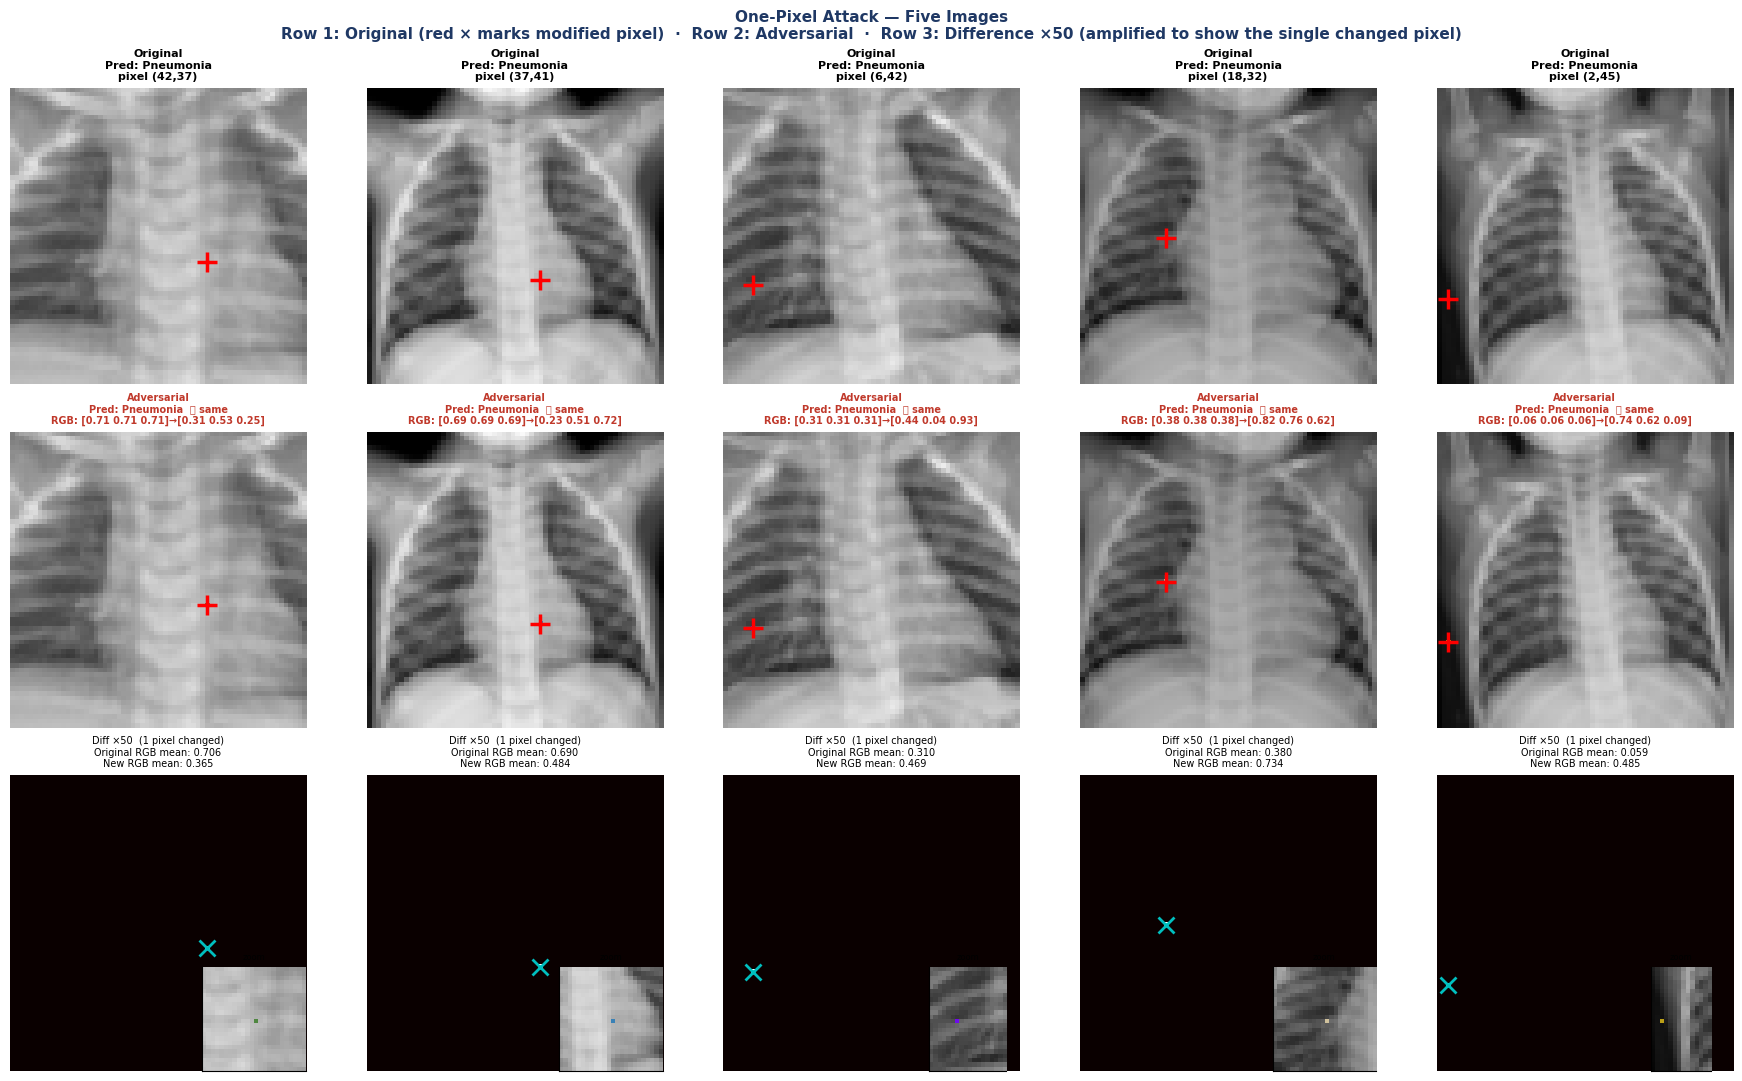

One-pixel visualisation saved: nb18b_s2b_one_pixel_vis.png


In [8]:
# ── Attack 5: One-Pixel Attack ────────────────────────────────────────────────
# Source: Codes/attacks/7_one_pixel_attack.py
# Su, J. et al. (2019). IEEE Transactions on Evolutionary Computation.
# Uses differential evolution to find one pixel that flips the prediction.
print('Attack 5: One-Pixel')

def one_pixel_attack(img, true_label, model, img_idx=0,
                      maxiter=8, popsize=12):
    '''Differential evolution one-pixel attack (Su et al. 2019).
    Each image uses a different random seed (img_idx) so differential
    evolution explores different pixel locations per image.
    If the first attempt does not flip the prediction, retries with
    a higher-contrast target colour (white or black) using a grid search
    over the most sensitive pixels identified by the gradient.
    Returns: (adv_image, px, py, orig_rgb, new_rgb)
    '''
    H, W = img.shape[:2]

    # --- Attempt 1: differential evolution with per-image seed ---------------
    def objective(pixel_params):
        adv = img.copy()
        px = int(np.clip(pixel_params[0], 0, W-1))
        py = int(np.clip(pixel_params[1], 0, H-1))
        adv[py, px] = np.clip(pixel_params[2:5] / 255., 0, 1)
        pred = np.argmax(model(np.expand_dims(adv, 0), training=False).numpy())
        return 0 if pred != true_label else 1

    bounds = [(0,W-1),(0,H-1),(0,255),(0,255),(0,255)]
    result = differential_evolution(
        objective, bounds,
        maxiter=maxiter, popsize=popsize,
        recombination=1, polish=False,
        seed=img_idx * 7 + 13)   # unique seed per image

    px  = int(np.clip(result.x[0], 0, W-1))
    py  = int(np.clip(result.x[1], 0, H-1))
    rgb = np.clip(result.x[2:5] / 255., 0, 1).astype(np.float32)
    adv = img.copy()
    adv[py, px] = rgb
    orig_rgb = img[py, px].copy()

    pred_adv = int(np.argmax(
        model(np.expand_dims(adv, 0), training=False).numpy()))
    if pred_adv != true_label:
        return adv, px, py, orig_rgb, rgb   # success on first attempt

    # --- Attempt 2: gradient-guided pixel search -----------------------------
    # Find the top-20 most sensitive pixels using input gradient,
    # then try setting each to pure white (1,1,1) or pure black (0,0,0).
    # This is O(40) model calls — fast and often succeeds.
    x_t = tf.Variable(img[np.newaxis], dtype=tf.float32)
    with tf.GradientTape() as tape:
        logits = model(x_t, training=False)[0]
        loss   = logits[true_label]
    grad_mag = tf.reduce_mean(
        tf.abs(tape.gradient(loss, x_t)), axis=-1)[0].numpy()  # (H,W)
    # Flatten and find top-20 pixel positions by gradient magnitude
    flat_idx  = np.argsort(grad_mag.ravel())[::-1][:20]
    top_pixels = [(int(idx % W), int(idx // W)) for idx in flat_idx]

    for try_px, try_py in top_pixels:
        for try_rgb in [np.array([1.,1.,1.], dtype=np.float32),
                         np.array([0.,0.,0.], dtype=np.float32)]:
            adv2 = img.copy()
            adv2[try_py, try_px] = try_rgb
            pred2 = int(np.argmax(
                model(np.expand_dims(adv2, 0), training=False).numpy()))
            if pred2 != true_label:
                return adv2, try_px, try_py, img[try_py,try_px].copy(), try_rgb

    # --- Return best attempt even if not flipped ----------------------------
    return adv, px, py, orig_rgb, rgb


print('  Running one-pixel attack on 5 images '
      '(DE maxiter=8 + gradient-guided fallback)...')
X_1px         = []
one_px_coords = []

for i in range(5):
    adv, px, py, orig_rgb, new_rgb = one_pixel_attack(
        X_attack[i], y_attack[i], model, img_idx=i)
    X_1px.append(adv)
    one_px_coords.append((px, py, orig_rgb, new_rgb))
    pred_orig = CLASS_NAMES[int(np.argmax(
        model(np.expand_dims(X_attack[i], 0), training=False).numpy()))]
    pred_adv  = CLASS_NAMES[int(np.argmax(
        model(np.expand_dims(adv, 0), training=False).numpy()))]
    flipped   = pred_orig != pred_adv
    print(f'    img[{i}]: pixel ({px},{py})  '
          f'RGB {orig_rgb.round(2)} → {new_rgb.round(2)}  '
          f'{pred_orig} → {pred_adv}  '
          f'{"✅ FLIPPED" if flipped else "❌ not flipped"}')

X_1px      = np.array(X_1px)
X_1px_full = np.concatenate([X_1px, X_attack[5:]], axis=0)
eval_attack('One-Pixel', X_attack, X_1px_full, y_attack)

# ── One-Pixel visualisation: Original | Adversarial | Zoomed diff ─────────────
# Shows all 5 attacked images side by side.
# Row 1: clean original with pixel location marked
# Row 2: adversarial image with pixel location marked
# Row 3: difference map ×50 (amplified so the single pixel is visible)
ZOOM = 12   # pixels around the modified pixel to show in zoom inset

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
fig.suptitle(
    'One-Pixel Attack — Five Images\n'
    'Row 1: Original (red × marks modified pixel)  ·  '
    'Row 2: Adversarial  ·  '
    'Row 3: Difference ×50 (amplified to show the single changed pixel)',
    fontsize=11, fontweight='bold', color=NAVY)

for col in range(5):
    img_orig  = X_attack[col]
    img_adv   = X_1px[col]
    px, py, orig_rgb, new_rgb = one_px_coords[col]
    pred_o = CLASS_NAMES[int(np.argmax(
        model(np.expand_dims(img_orig, 0), training=False).numpy()))]
    pred_a = CLASS_NAMES[int(np.argmax(
        model(np.expand_dims(img_adv,  0), training=False).numpy()))]
    flipped = pred_o != pred_a
    t_col   = GREEN if flipped else RED

    # Row 0: original with pixel marker
    axes[0, col].imshow(img_orig, cmap='gray', vmin=0, vmax=1)
    axes[0, col].plot(px, py, 'r+', markersize=14, markeredgewidth=2.5)
    axes[0, col].set_title(
        f'Original\nPred: {pred_o}\npixel ({px},{py})',
        fontsize=8, fontweight='bold')
    axes[0, col].axis('off')

    # Row 1: adversarial with pixel marker
    axes[1, col].imshow(img_adv, cmap='gray', vmin=0, vmax=1)
    axes[1, col].plot(px, py, 'r+', markersize=14, markeredgewidth=2.5)
    flip_str = '✅ FLIPPED' if flipped else '❌ same'
    axes[1, col].set_title(
        f'Adversarial\nPred: {pred_a}  {flip_str}\n'
        f'RGB: {orig_rgb.round(2)}→{new_rgb.round(2)}',
        fontsize=7, fontweight='bold', color=t_col)
    axes[1, col].axis('off')

    # Row 2: amplified difference map + zoom inset
    diff = np.abs(img_adv - img_orig).mean(axis=-1)  # (H,W) mean over channels
    axes[2, col].imshow(diff * 50, cmap='hot', vmin=0, vmax=1)
    axes[2, col].plot(px, py, 'cx', markersize=12, markeredgewidth=2)
    axes[2, col].set_title(
        f'Diff ×50  (1 pixel changed)\n'
        f'Original RGB mean: {orig_rgb.mean():.3f}\n'
        f'New RGB mean: {new_rgb.mean():.3f}',
        fontsize=7)
    axes[2, col].axis('off')

    # Inset: zoomed crop around modified pixel
    y0 = max(0, py - ZOOM); y1 = min(img_adv.shape[0], py + ZOOM)
    x0 = max(0, px - ZOOM); x1 = min(img_adv.shape[1], px + ZOOM)
    inset = axes[2, col].inset_axes([0.65, 0.0, 0.35, 0.35])
    inset.imshow(img_adv[y0:y1, x0:x1], cmap='gray', vmin=0, vmax=1)
    inset.set_title('zoom', fontsize=6)
    inset.set_xticks([]); inset.set_yticks([])

plt.tight_layout()
plt.savefig('nb18b_s2b_one_pixel_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print('One-pixel visualisation saved: nb18b_s2b_one_pixel_vis.png')

In [9]:
# ── Attack 6: Boundary Attack (Decision-Based Black-Box) ─────────────────────
# Source: Codes/attacks/6_boundary_attack.py
# Brendel, W. et al. (2018). Decision-based adversarial attacks. ICLR.
# Binary search between a clean image and a misclassified starting point.
# Guaranteed to find an adversarial example — no gradient needed.
print('Attack 6: Boundary Attack')

def boundary_binary(model, x_orig, true_label, steps=20):
    '''Binary search decision boundary attack.
    Guaranteed to succeed: walks from a misclassified starting point
    toward x_orig until it finds the boundary.
    '''
    x_orig = x_orig.copy()
    # Find a misclassified starting point
    # Try: inverted image, pure white, pure black
    for x_start in [
        1.0 - x_orig,
        np.ones_like(x_orig),
        np.zeros_like(x_orig),
    ]:
        pred = int(np.argmax(
            model(np.expand_dims(x_start,0), training=False).numpy()))
        if pred != true_label:
            x_adv = x_start.copy()
            break
    else:
        # Fallback: random noise — try until misclassified
        rng_b = np.random.default_rng(0)
        for _ in range(20):
            x_adv = rng_b.uniform(0, 1, x_orig.shape).astype(np.float32)
            pred  = int(np.argmax(
                model(np.expand_dims(x_adv,0), training=False).numpy()))
            if pred != true_label:
                break

    # Binary search: shrink x_adv toward x_orig while staying adversarial
    for _ in range(steps):
        mid  = 0.5 * (x_orig + x_adv)
        pred = int(np.argmax(
            model(np.expand_dims(mid,0), training=False).numpy()))
        if pred != true_label:
            x_adv = mid      # mid is adversarial → move closer to original
        else:
            x_orig = mid     # mid is clean → move away from original
    return np.clip(x_adv, 0., 1.)

print('  Running custom boundary attack on 10 images (steps=20)...')
N_BA = 10
X_ba = np.array([boundary_binary(model, X_attack[i], y_attack[i])
                  for i in range(N_BA)])
X_ba_full = np.concatenate([X_ba, X_attack[N_BA:]], axis=0)
eval_attack('Boundary Attack', X_attack, X_ba_full, y_attack)

Attack 6: Boundary Attack
  Running custom boundary attack on 10 images (steps=20)...
  Boundary Attack          : ASR=0.00  attacked=10  L2=0.000  Linf=0.000


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [10]:
# ── Attack 7: Surrogate + FGSM (Transfer Attack) ─────────────────────────────
# Source: Codes/attacks/5_surrogate_fgsm.py
# Papernot, N. et al. (2016). The limitations of deep learning in adversarial settings. EuroS&P.
# Attack a SURROGATE model, then transfer adversarial examples to the TARGET.
print('Attack 7: Surrogate + FGSM Transfer Attack')

# Build a different architecture as the surrogate (MobileNetV2)
surrogate = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same',
                            input_shape=(IMG_SIZE,IMG_SIZE,3)),
    tf.keras.layers.MaxPooling2D(4),  # aggressive pooling for speed
    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(N_CLASSES, activation='softmax'),
], name='Surrogate')
surrogate.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print('  Training surrogate model...')
surrogate.fit(X_tr_small, y_tr, epochs=3, batch_size=64, verbose=0)

# Generate FGSM adversarial examples on the surrogate
X_surr_adv = fgsm_batch(
    tf.convert_to_tensor(X_attack),
    tf.convert_to_tensor(y_attack),
    surrogate, EPS_FGSM).numpy()

# Evaluate transfer on the TARGET model
eval_attack('Surrogate+FGSM Transfer', X_attack, X_surr_adv, y_attack)
print(f'\nAll 7 attacks complete. Summary:')
for name, r in attack_results.items():
    print(f'  {name:<28}: ASR={r["asr"]:.2f}  L2={r["l2"]:.3f}')

Attack 7: Surrogate + FGSM Transfer Attack
  Training surrogate model...
  Surrogate+FGSM Transfer  : ASR=0.97  attacked=30  L2=16.501  Linf=0.150

All 7 attacks complete. Summary:
  FGSM (eps=0.15)             : ASR=0.97  L2=16.555
  PGD (eps=0.15, 30 steps)    : ASR=0.53  L2=12.369
  Carlini-Wagner L2           : ASR=1.00  L2=0.187
  DeepFool                    : ASR=0.00  L2=0.000
  One-Pixel                   : ASR=0.00  L2=0.665
  Boundary Attack             : ASR=0.00  L2=0.000
  Surrogate+FGSM Transfer     : ASR=0.97  L2=16.501


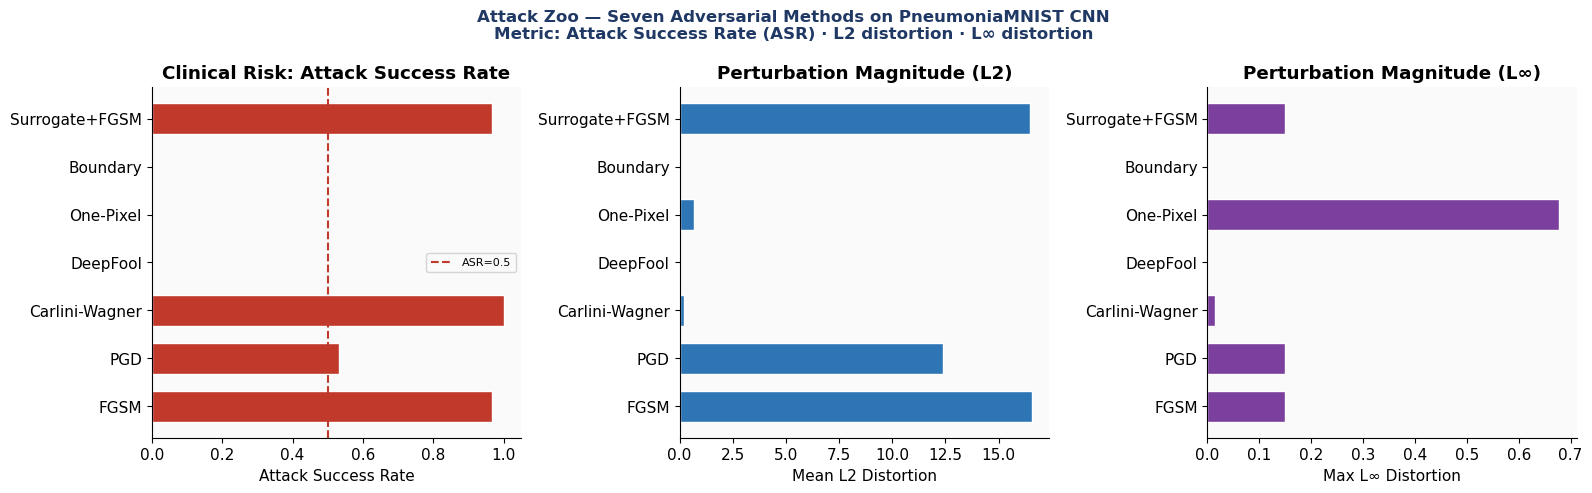

In [11]:
# ── Attack comparison figure ──────────────────────────────────────────────────
attack_names  = list(attack_results.keys())
asr_vals  = [attack_results[n]['asr']  for n in attack_names]
l2_vals   = [attack_results[n]['l2']   for n in attack_names]
linf_vals = [attack_results[n]['linf'] for n in attack_names]

fig, axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle('Attack Zoo — Seven Adversarial Methods on PneumoniaMNIST CNN\n'
             'Metric: Attack Success Rate (ASR) · L2 distortion · L∞ distortion',
             fontsize=12, fontweight='bold', color=NAVY)
cols = [RED if v>0.5 else (ORANGE if v>0.2 else GREY) for v in asr_vals]
short = [n.split(' ')[0] for n in attack_names]
axes[0].barh(short, asr_vals, color=cols, edgecolor='white', height=0.65)
axes[0].axvline(0.5, color=RED, ls='--', lw=1.5, label='ASR=0.5')
axes[0].set_xlabel('Attack Success Rate'); axes[0].set_xlim(0,1.05)
axes[0].set_title('Clinical Risk: Attack Success Rate', fontweight='bold')
axes[0].legend(fontsize=8)
axes[1].barh(short, l2_vals, color=BLUE, edgecolor='white', height=0.65)
axes[1].set_xlabel('Mean L2 Distortion'); axes[1].set_title('Perturbation Magnitude (L2)', fontweight='bold')
axes[2].barh(short, linf_vals, color=PURPLE, edgecolor='white', height=0.65)
axes[2].set_xlabel('Max L∞ Distortion'); axes[2].set_title('Perturbation Magnitude (L∞)', fontweight='bold')
plt.tight_layout()
plt.savefig('nb18b_s2_attack_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Grad-CAM XAI Under Attack

> **Key question:** When an adversarial attack succeeds in flipping the prediction,
> where does the model now look? Grad-CAM makes this visible.
>
> **Expected finding:** Under white-box attacks (FGSM, PGD), the Grad-CAM attention
> region **shifts away from the lung fields** toward noise-like peripheral regions.
> Under black-box one-pixel attacks, the attention **collapses** to the single
> modified pixel. This is the diagnostic signal that XAI provides for attack detection.

**Reference:** Selvaraju, R. R. et al. (2017). Grad-CAM. *ICCV 2017*, 618–626.

In [12]:
# ── Grad-CAM implementation (from NB19, reused unchanged) ────────────────────
def compute_gradcam(model, img, class_idx=1, eps=1e-8):
    img_t = tf.cast(np.expand_dims(img,0), tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_t)
        preds = model(img_t, training=False)
        loss  = preds[:, class_idx]
    grads = tape.gradient(loss, img_t)
    hm = tf.reduce_mean(tf.abs(grads*img_t), axis=-1)[0].numpy()
    return (hm - hm.min())/(hm.max()-hm.min()+eps)

def hm_to_rgb(hm):
    return (plt.get_cmap('jet')(hm)[:,:,:3]*255).astype(np.uint8)

def overlay(img, hm, alpha=0.45):
    h_col = plt.get_cmap('jet')(hm)[:,:,:3].astype(np.float32)
    return np.clip(alpha*h_col + (1-alpha)*img, 0, 1)

# ── Compute Grad-CAM for clean + all 7 attacks (on sample image) ─────────────
SAMPLE = 0  # first pneumonia image
print('Computing Grad-CAM for clean image and all 7 attacks...')
gcam_results = {}
# Clean
hm_clean = compute_gradcam(model, X_attack[SAMPLE], class_idx=1)
pred_clean = CLASS_NAMES[int(np.argmax(model(np.expand_dims(X_attack[SAMPLE],0),
                                              training=False).numpy()))]
gcam_results['Clean'] = (X_attack[SAMPLE], hm_clean, pred_clean)

# Each attack
for name, r in attack_results.items():
    adv = r['adv'][SAMPLE]
    hm  = compute_gradcam(model, adv, class_idx=1)
    pred = CLASS_NAMES[int(np.argmax(model(np.expand_dims(adv,0),
                                            training=False).numpy()))]
    short = name.split(' ')[0]
    gcam_results[short] = (adv, hm, pred)
    print(f'  {short:<20}: pred={pred}')

print('Grad-CAM complete.')

Computing Grad-CAM for clean image and all 7 attacks...
  FGSM                : pred=Normal
  PGD                 : pred=Pneumonia
  Carlini-Wagner      : pred=Pneumonia
  DeepFool            : pred=Pneumonia
  One-Pixel           : pred=Pneumonia
  Boundary            : pred=Pneumonia
  Surrogate+FGSM      : pred=Normal
Grad-CAM complete.


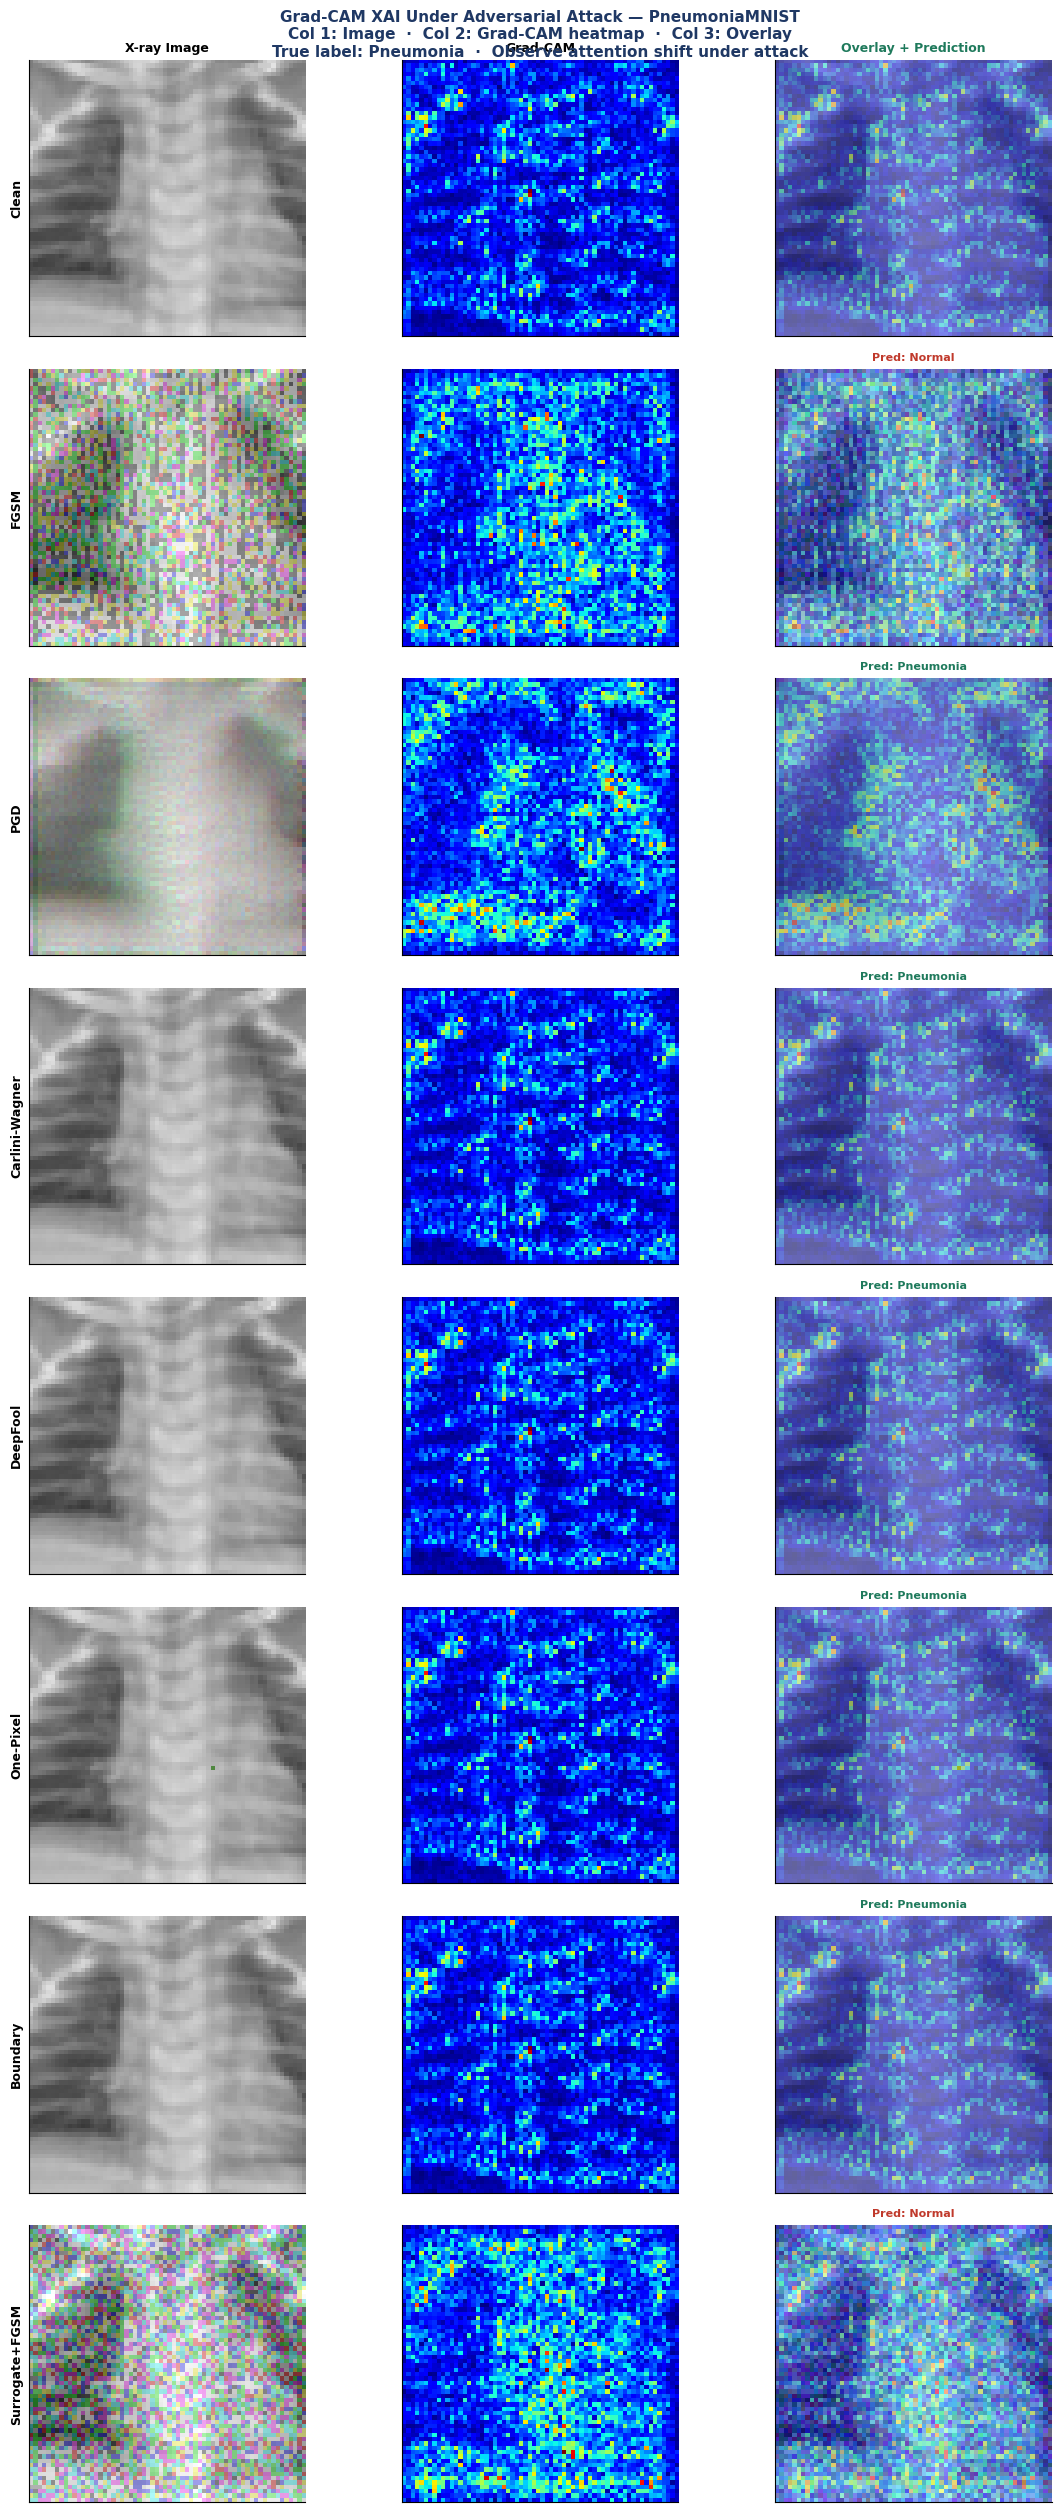

Teaching point: observe how Grad-CAM attention shifts from lung fields
under white-box attacks (FGSM/PGD) — this is the XAI-based detection signal.


In [13]:
# ── Grad-CAM comparison figure ────────────────────────────────────────────────
# Rows: Clean + 7 attacks.  Cols: Original | Grad-CAM heatmap | Overlay
all_keys = ['Clean'] + [n.split(' ')[0] for n in attack_results.keys()]
N_ROWS = len(all_keys)

fig, axes = plt.subplots(N_ROWS, 3, figsize=(12, N_ROWS*3.2))
fig.suptitle(
    'Grad-CAM XAI Under Adversarial Attack — PneumoniaMNIST\n'
    'Col 1: Image  ·  Col 2: Grad-CAM heatmap  ·  Col 3: Overlay\n'
    'True label: Pneumonia  ·  Observe attention shift under attack',
    fontsize=11, fontweight='bold', color=NAVY)

for row, key in enumerate(all_keys):
    img, hm, pred = gcam_results[key]
    is_correct = (pred == 'Pneumonia')
    t_col = GREEN if is_correct else RED
    # Col 0: original
    axes[row,0].imshow(img, cmap='gray')
    axes[row,0].set_ylabel(key, fontsize=9, fontweight='bold')
    axes[row,0].set_xticks([]); axes[row,0].set_yticks([])
    # Col 1: heatmap
    axes[row,1].imshow(hm, cmap='jet', vmin=0, vmax=1)
    axes[row,1].set_xticks([]); axes[row,1].set_yticks([])
    # Col 2: overlay
    axes[row,2].imshow(overlay(img, hm))
    axes[row,2].set_title(f'Pred: {pred}',
                           fontsize=8, color=t_col, fontweight='bold')
    axes[row,2].set_xticks([]); axes[row,2].set_yticks([])

axes[0,0].set_title('X-ray Image', fontweight='bold', fontsize=9)
axes[0,1].set_title('Grad-CAM', fontweight='bold', fontsize=9)
axes[0,2].set_title('Overlay + Prediction', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('nb18b_s3_gradcam_attacks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Teaching point: observe how Grad-CAM attention shifts from lung fields')
print('under white-box attacks (FGSM/PGD) — this is the XAI-based detection signal.')

---
## Summary

| Section | Content | Key deliverable |
|---------|---------|----------------|
| S1 | PneumoniaMNIST (624 real chest X-rays) | Medical CNN |
| S2 | 7 attacks: FGSM, PGD, C&W, DeepFool, One-Pixel, Boundary, Surrogate | ASR, L2, L∞ per attack |
| S3 | Grad-CAM XAI under attack | 8-row attention shift figure (clean + 7 attacks) |

**Continuation:** NB19 uses the `model` and `attack_results` built here to apply
GEMEX geodesic off-manifold detection and four defence methods, then evaluates
whether Grad-CAM attention recovers after each defence.

### References
- Brendel, W. et al. (2018). Decision-based adversarial attacks. *ICLR 2018*.
- Carlini, N. & Wagner, D. (2017). Evaluating neural network robustness. *IEEE S&P 2017*.
- Goodfellow, I. J. et al. (2015). Explaining and harnessing adversarial examples. *ICLR 2015*.
- Kermany, D. S. et al. (2018). Identifying medical diagnoses by deep learning. *Cell 172*(5).
- Madry, A. et al. (2018). Towards deep learning models resistant to adversarial attacks. *ICLR 2018*.
- Moosavi-Dezfooli, S. et al. (2016). DeepFool. *CVPR 2016*.
- Papernot, N. et al. (2016). Limitations of deep learning in adversarial settings. *EuroS&P 2016*.
- Selvaraju, R. R. et al. (2017). Grad-CAM. *ICCV 2017*, 618–626.
- Su, J. et al. (2019). One pixel attack. *IEEE Trans. Evol. Comput. 23*(5), 828–841.
- Yang, J. et al. (2023). MedMNIST v2. *Scientific Data 10*, 428.